In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import SimpleITK
import itk

In [2]:
info_file = '../../data/dual_energy_submission_label/label_submission_new.csv'
df_info = pd.read_csv(info_file)
key_name = 'DualEnergy BoneRemovalHead Suppressed'
df_info.head()
BoneRemovalHead_dict = {}
BoneRemovalHead_vr_dict = {}
for index, row in df_info.iterrows():
    if key_name in row['info']:
        BoneRemovalHead_dict[row['seriesInstanceUID']] = row['studyInstanceUID']

In [3]:
print('BoneRemovalHead_dict size:\t{}'.format(len(BoneRemovalHead_dict)))
# root_dir = '/ssd2/zhangwd/data/brain/dual_energy_substraction1/bystudy'
root_dir = '/data/zhangwd/data/examples/brain/bystudy'
os.makedirs('/data/zhangwd/data/examples/brain/bone_removed', exist_ok=True)
with open('/data/zhangwd/data/examples/brain/bone_removed/removed_dicom.txt', 'w') as f:
    for key, val in BoneRemovalHead_dict.items():
        f.write('{}/{}/{}\n'.format(root_dir, val, key))

BoneRemovalHead_dict size:	32


In [4]:
root_dir = '/ssd2/zhangwd/data/brain/dual_energy_substraction1/bystudy'
# root_dir = '/data/zhangwd/data/examples/brain/bystudy'
series_uid = list(BoneRemovalHead_dict.keys())[0]
series_uid = os.path.join(root_dir, BoneRemovalHead_dict[series_uid], series_uid)

In [5]:
reader = SimpleITK.ImageSeriesReader()
filenamesDICOM = reader.GetGDCMSeriesFileNames(series_uid)
reader.SetFileNames(filenamesDICOM)
imgOriginal = reader.Execute()

In [6]:
PixelType = itk.ctype('short')
Dimension = 2
ImageType = itk.Image[PixelType, Dimension]
ImageType

itkImagePython.itkImageSS2

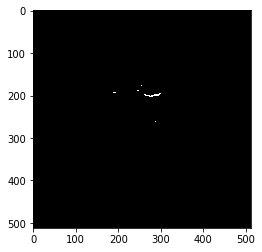

In [7]:
reader = itk.ImageFileReader[ImageType].New()
inputImage = '/ssd2/zhangwd/data/brain/dual_energy_substraction1/bystudy/1.3.12.2.1107.5.1.4.60320.30000016072900171834200000026/1.3.12.2.1107.5.99.2.9594.30000016072913081812500000799/000144.dcm'
reader.SetFileName(inputImage)
thresholdFilter = itk.BinaryThresholdImageFilter[ImageType, ImageType].New()
thresholdFilter.SetInput(reader.GetOutput())


lowerThreshold = 200
upperThreshold = 700
outsideValue = 0
insideValue = 255
thresholdFilter.SetLowerThreshold(lowerThreshold)
thresholdFilter.SetUpperThreshold(upperThreshold)
thresholdFilter.SetOutsideValue(outsideValue)
thresholdFilter.SetInsideValue(insideValue)

mask = thresholdFilter.GetOutput()
mask = itk.GetArrayFromImage(mask)

plt.figure()
plt.imshow(mask, cmap='gray')

In [8]:
def extract_vessel_single_dcm(dcm_file):
    PixelType = itk.ctype('short')
    Dimension = 2
    ImageType = itk.Image[PixelType, Dimension]
    reader = itk.ImageFileReader[ImageType].New()
    inputImage = dcm_file
    reader.SetFileName(inputImage)
    thresholdFilter = itk.BinaryThresholdImageFilter[ImageType, ImageType].New()
    thresholdFilter.SetInput(reader.GetOutput())
    
    thresholdFilter.SetLowerThreshold(lowerThreshold)
    thresholdFilter.SetUpperThreshold(upperThreshold)
    thresholdFilter.SetOutsideValue(outsideValue)
    thresholdFilter.SetInsideValue(insideValue)
    
    mask = thresholdFilter.GetOutput()
    mask = itk.GetArrayFromImage(mask)
    
    return mask

def extract_vessl_series_uid(series_uid):
    reader = SimpleITK.ImageSeriesReader()
    filenamesDICOM = reader.GetGDCMSeriesFileNames(series_uid)
    mask = np.zeros([len(filenamesDICOM), 512, 512])
    for index,dcm in enumerate(filenamesDICOM):
        single_mask = extract_vessel_single_dcm(dcm)
        mask[index,:,:] = single_mask
    return mask

In [9]:
reader = SimpleITK.ImageSeriesReader()
series_uid = '/ssd2/zhangwd/data/brain/dual_energy_substraction1/bystudy/1.3.12.2.1107.5.1.4.60320.30000016072900171834200000026/1.3.12.2.1107.5.99.2.9594.30000016072913081812500000799'
filenamesDICOM = reader.GetGDCMSeriesFileNames(series_uid)
filenamesDICOM

('/ssd2/zhangwd/data/brain/dual_energy_substraction1/bystudy/1.3.12.2.1107.5.1.4.60320.30000016072900171834200000026/1.3.12.2.1107.5.99.2.9594.30000016072913081812500000799/000339.dcm',
 '/ssd2/zhangwd/data/brain/dual_energy_substraction1/bystudy/1.3.12.2.1107.5.1.4.60320.30000016072900171834200000026/1.3.12.2.1107.5.99.2.9594.30000016072913081812500000799/000338.dcm',
 '/ssd2/zhangwd/data/brain/dual_energy_substraction1/bystudy/1.3.12.2.1107.5.1.4.60320.30000016072900171834200000026/1.3.12.2.1107.5.99.2.9594.30000016072913081812500000799/000337.dcm',
 '/ssd2/zhangwd/data/brain/dual_energy_substraction1/bystudy/1.3.12.2.1107.5.1.4.60320.30000016072900171834200000026/1.3.12.2.1107.5.99.2.9594.30000016072913081812500000799/000336.dcm',
 '/ssd2/zhangwd/data/brain/dual_energy_substraction1/bystudy/1.3.12.2.1107.5.1.4.60320.30000016072900171834200000026/1.3.12.2.1107.5.99.2.9594.30000016072913081812500000799/000335.dcm',
 '/ssd2/zhangwd/data/brain/dual_energy_substraction1/bystudy/1.3.12.2.

In [10]:
mask = extract_vessl_series_uid(series_uid)

In [11]:
mask.shape

(339, 512, 512)

In [12]:
import nibabel as nib
mask_img = itk.GetImageFromArray(mask)

In [13]:
np.save('test.raw', mask)

In [14]:
mask = np.transpose(mask, [1,2,0])
mask_img = nib.Nifti1Image(mask, affine=np.eye(4))
nib.save(mask_img, 'test.nii')